# Library imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
import cartopy.crs as ccrs
from sklearn.metrics import r2_score
pd.set_option('display.float_format', lambda x: '%.2f' % x)
np.set_printoptions(suppress=True)

In [3]:
def find_coeffs(X, y):
    """
    Linear regression algorithm. 
    Input x = [x0,x1,x2,...,x_n], where x0 is a vector of ones (intercept bias of the regression)
    Input y = [y0,y1,y2,y_n] 
    Output beta = the weights of the linear regression model.
    """
    
    # The Normal Equation (closed form of the linear regression problem)
    beta = np.dot(np.linalg.inv(np.dot(X.T, X)), np.dot(X.T, y))
    
    return beta

# Dataset overview

In [4]:
gridded_atlantic_storms = pd.read_csv('gridded_atlantic_storms.csv')
gridded_atlantic_storms['year'] = pd.DatetimeIndex(gridded_atlantic_storms['date']).year
display(gridded_atlantic_storms.head(5))

grid_data = pd.read_excel('grid_data_edited_vickery.xlsx')
nb_cells_grid = grid_data['grid_ids'].max()
display(grid_data.head(5))

,id,name,date,record_identifier,status_of_system,latitude,longitude,maximum_sustained_wind_knots,maximum_pressure,34_kt_ne,...,Int_ip1,SST_p1,ln_Int,ln_Int_im1,ln_Int_im2,ln_Int_ip1,delta_SST,pc_comp,grid_ids,year
0,AL011851,UNNAMED,1851-06-25 00:00:00,NaN,HU,28.00,-94.80,80,NaN,NaN,...,0.06,301.10,-2.87,NaN,NaN,-2.87,-0.07,974.27,70,1851
1,AL011851,UNNAMED,1851-06-25 06:00:00,NaN,HU,28.00,-95.40,80,NaN,NaN,...,0.06,301.03,-2.87,-2.87,NaN,-2.87,-0.07,974.27,69,1851
2,AL011851,UNNAMED,1851-06-25 12:00:00,NaN,HU,28.00,-96.00,80,NaN,NaN,...,0.06,300.98,-2.87,-2.87,-2.87,-2.87,-0.05,974.27,69,1851
3,AL011851,UNNAMED,1851-06-25 18:00:00,NaN,HU,28.10,-96.50,80,NaN,NaN,...,0.06,300.98,-2.87,-2.87,-2.87,-2.87,0.00,974.06,69,1851
4,AL011851,UNNAMED,1851-06-25 21:00:00,L,HU,28.20,-96.80,80,NaN,NaN,...,NaN,NaN,-2.87,-2.87,-2.87,NaN,NaN,974.24,69,1851


,grid_ids,longitude,latitude,E_alpha_coeffs_ed,E_beta_coeffs_ed,W_alpha_coeffs_ed,W_beta_coeffs_ed
0,1,107.50,12.50,"[(781.1682535056025, 0.45729229192147614, -0.7...","[(540938.0758666992, 1005.0017541646957, 6143....","[(7.49746074093855, 0.4886387502765501, -0.078...","[(57.74840532336384, -2.1843964177724047, 0.43..."
1,2,102.50,12.50,"[(781.1682535056025, 0.45729229192147614, -0.7...","[(540938.0758666992, 1005.0017541646957, 6143....","[(7.49746074093855, 0.4886387502765501, -0.078...","[(57.74840532336384, -2.1843964177724047, 0.43..."
2,3,97.50,12.50,"[(781.1682535056025, 0.45729229192147614, -0.7...","[(540938.0758666992, 1005.0017541646957, 6143....","[(1.080523581669695, 0.6875383483909303, -0.02...","[(-103.21421744820691, 6.361451755320463, 0.30..."
3,4,92.50,12.50,"[(781.1682535056025, 0.45729229192147614, -0.7...","[(540938.0758666992, 1005.0017541646957, 6143....","[(4.183174132303066, 0.9780265321125654, 0.111...","[(22.31406519614029, 5.649775028162566, 1.2457..."
4,5,87.50,12.50,"[(-2.649725156294153, 0.8829161186806935, 0.04...","[(-332.59685801367596, 0.010390189105976333, -...","[(0.7860770944771502, 0.9550862831322746, 0.03...","[(115.77908584475517, -1.3330109702169892, 1.2..."


# Remove invalid inputs towards coefficients training 

In [5]:
print(f'Prior to any data clipping, the DataFrame has the following shape : {gridded_atlantic_storms.shape}')
# Clear values where no intensity could be processed (applying to Int will also apply to ln_Int) :
#gridded_atlantic_storms = gridded_atlantic_storms[gridded_atlantic_storms['maximum_pressure'].notnull()]
gridded_atlantic_storms = gridded_atlantic_storms[gridded_atlantic_storms['Int_ip1'].notnull()]
gridded_atlantic_storms = gridded_atlantic_storms[gridded_atlantic_storms['Int'].notnull()]

# Fill in with 0s rows where no previous intensity measure is identified
gridded_atlantic_storms = gridded_atlantic_storms.fillna(value = {"ln_Int_im1":0,"ln_Int_im2":0})

# Data clipping according to year :
min_year = 1850 # first year to exclude.
max_year = 2021 # year to start excluding.

##############

#edited_gridded_atlantic_storms = gridded_atlantic_storms

#############
print(f'Following data clipping of null values, the DataFrame shape is : {gridded_atlantic_storms.shape}')

edited_gridded_atlantic_storms = gridded_atlantic_storms[gridded_atlantic_storms.year > min_year]
edited_gridded_atlantic_storms = edited_gridded_atlantic_storms[edited_gridded_atlantic_storms.year < max_year]
# Data clipping according to maximum intensity (should not exceed 1)
#max_int = 1.26
#max_int = 3.5
#edited_gridded_atlantic_storms = edited_gridded_atlantic_storms[edited_gridded_atlantic_storms.Int < max_int]
print(f'The final shape, after additional clipping is : {edited_gridded_atlantic_storms.shape}')

Prior to any data clipping, the DataFrame has the following shape : (52028, 52)
Following data clipping of null values, the DataFrame shape is : (43235, 52)
The final shape, after additional clipping is : (43235, 52)


# Quick overview of the remaining intensities

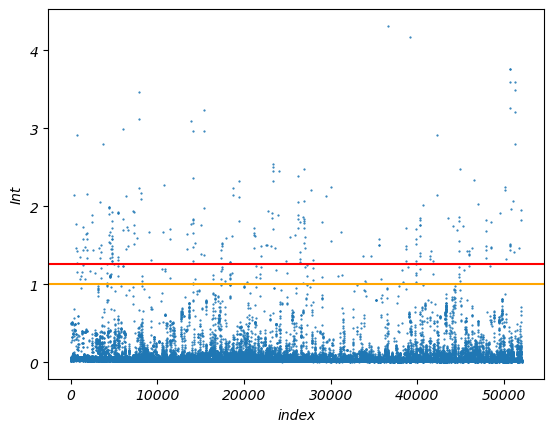

In [6]:
edited_gridded_atlantic_storms.reset_index().plot.scatter(x= 'index',y = 'Int', s =0.3)
# According to Darling 1991, some values above 1.26 were observed.
plt.axhline(y=1.26, color='r', linestyle='-')
plt.axhline(y=1, color='orange', linestyle='-')

# Assess the heading direction and split into according dataframes :

In [7]:
# Create a dictionary to compile all dataframes subsetted per cell id and direction (west versus east) : 
df = {}

for i in range(nb_cells_grid) : 
    ds_in_grid = edited_gridded_atlantic_storms.loc[edited_gridded_atlantic_storms['grid_ids'] == i+1]
    west_ds = ds_in_grid[ds_in_grid['E_or_W']== 'W']
    east_ds = ds_in_grid[ds_in_grid['E_or_W']== 'E']

    df[f'W{i+1}'] = pd.DataFrame(west_ds)
    df[f'E{i+1}'] = pd.DataFrame(east_ds)

# To get a quick look in table format: 
Visualize = False

if Visualize == True : 
    for ids, dataframe in df.items() : 
        display(dataframe)

# Coefficient fitting and modeling errors : 

Plotting the intensity graphs for cell E146.
R2-score: 0.58


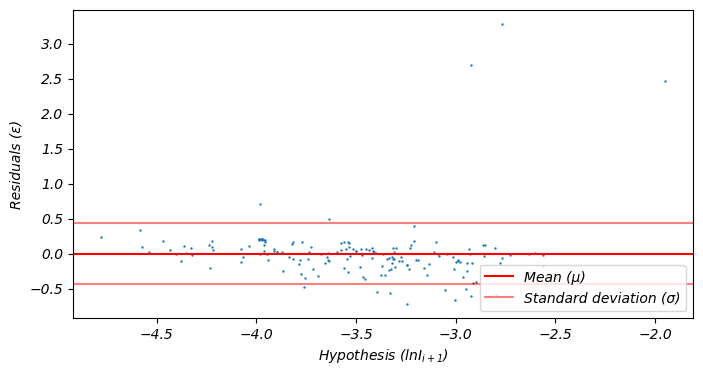

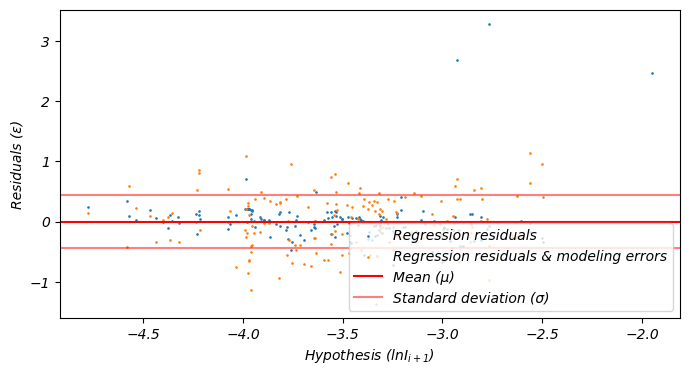

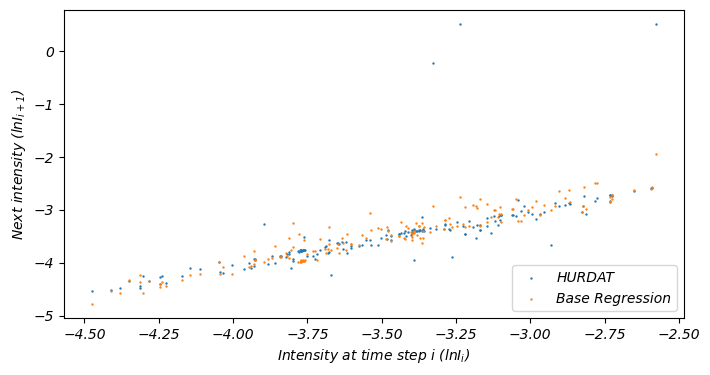

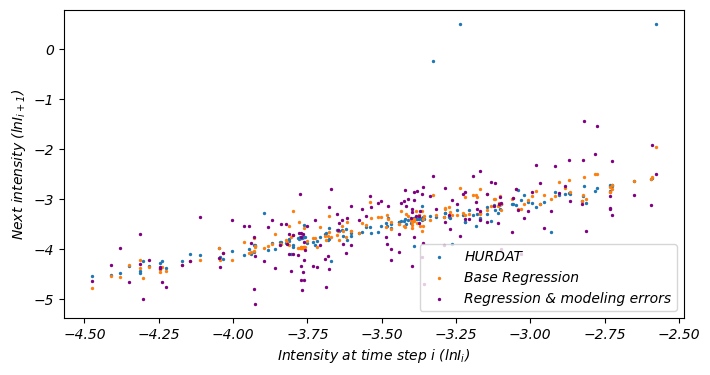

Mu : 0.00 and std 0.43
Mu : -0.02 and std 0.46


In [8]:
Coeffs_E = []
Coeffs_W = []

for key in list(df.keys()) :  
    Heading = key[0]
    grid_id = key[1:]   
    grid_look_up = Heading+grid_id    
    
    if Heading == 'E' : 
        # Liu 2014 recommands not to perform regressions on cells with less than 6 datasets : 
        if df[grid_look_up].shape[0] >= 6 : 
            #---------------------------------------------------------
            # Extract the base coefficients for the intensity model : 
            # The known target outputs :             
            y_I = np.asanyarray(df[grid_look_up]['ln_Int_ip1'])            
             
            # The features : 
            x_0 = np.ones([df[grid_look_up].shape[0],1]) # x0 + formatting the array
            #x1 = df['Ei']['ln_I']        # x1 = ln(I)       = Intensity at current step
            #x2 = df['Ei']['ln_im1']      # x2 = ln(I_(i-1)) = Intensity 1 step ago
            #x3 = df['Ei']['ln_im2']      # x3 = ln(I_(i-2)) = Intensity two steps ago
            #x4 = df['Ei']['SST']         # x4 = SST         = SST temperature at current step 
            #x5 = df['Ei']['delta_SST']   # x5 = delta_SST   = SST temperature variation to next step

            # Lets just acquire everything in one go : 
            x = np.asanyarray(df[grid_look_up][['ln_Int','ln_Int_im1','ln_Int_im2','SST','delta_SST']])            
            
            # Assemble the features : 
            X_I = np.concatenate((x_0,x), axis =1)            
            
            # Find the regression coefficients :
            kappa = find_coeffs(X_I,y_I)            
            
            # Error residuals :             
            y_hat_I =np.matmul(X_I,kappa)
            residuals_intensity = y_I-y_hat_I
            mean_res_I = np.mean(residuals_intensity)
            std_res_I = np.std(residuals_intensity, ddof = 1)
            #print(f'Mu : {mean_res_I:.2f} and std {std_res_I:.2f}')        
            
            # Linear transformations on the student T distribution for the residuals: 
            # Main parameters required to model the residuals : 
            dgr_of_frdm_I = y_hat_I.shape[0]-1
            residuals_I = (dgr_of_frdm_I,std_res_I)
            
            # Group the regression coefficients with the residuals main parameters : 
            kappa_coeffs_I = []
            kappa_coeffs_I.append(tuple(kappa))
            kappa_coeffs_I.append(residuals_I)
            
            #-----------------------------------------------------            
            # Associate to corresponding grid :  
            Coeffs_E.append([int(grid_id),kappa_coeffs_I])                      
        else : 
            Coeffs_E.append([int(grid_id),np.nan])

    if Heading == 'W' : 
        # Liu 2014 recommands not to perform regressions on cells with less than 6 datasets : 
        if df[grid_look_up].shape[0] >= 6 : 
            #---------------------------------------------------------
            # Extract the base coefficients for the intensity model : 
            # The known target outputs :             
            y_I = np.asanyarray(df[grid_look_up]['ln_Int_ip1'])            
             
            # The features : 
            x_0 = np.ones([df[grid_look_up].shape[0],1]) # x0 + formatting the array
            #x1 = df['Wi']['ln_I']        # x1 = ln(I)       = Intensity at current step
            #x2 = df['Wi']['ln_im1']      # x2 = ln(I_(i-1)) = Intensity 1 step ago
            #x3 = df['Wi']['ln_im2']      # x3 = ln(I_(i-2)) = Intensity two steps ago
            #x4 = df['Wi']['SST']         # x4 = SST         = SST temperature at current step 
            #x5 = df['Wi']['delta_SST']   # x5 = delta_SST   = SST temperature variation to next step

            # Lets just acquire everything in one go : 
            x = np.asanyarray(df[grid_look_up][['ln_Int','ln_Int_im1','ln_Int_im2','SST','delta_SST']])            
            
            # Assemble the features : 
            X_I = np.concatenate((x_0,x), axis =1)            
            
            # Find the regression coefficients :
            kappa = find_coeffs(X_I,y_I) 

            
            # Error residuals :             
            y_hat_I =np.matmul(X_I,kappa)
            residuals_intensity = y_I-y_hat_I
            mean_res_I = np.mean(residuals_intensity)
            std_res_I = np.std(residuals_intensity, ddof = 1)
            #print(f'Mu : {mean_res_I:.2f} and std {std_res_I:.2f}')        
            
            # Linear transformations on the student T distribution for the residuals: 
            # Main parameters required to model the residuals : 
            dgr_of_frdm_I = y_hat_I.shape[0]-1
            residuals_I = (dgr_of_frdm_I,std_res_I)
            
            # Group the regression coefficients with the residuals main parameters : 
            kappa_coeffs_I = []
            kappa_coeffs_I.append(tuple(kappa))
            kappa_coeffs_I.append(residuals_I)
            
            #-----------------------------------------------------            
            # Associate to corresponding grid :  
            Coeffs_W.append([int(grid_id),kappa_coeffs_I])                      
        else : 
            Coeffs_W.append([int(grid_id),np.nan])
    
            
    Plot_one = True
        
    if grid_look_up == 'E146' and Plot_one == True :                         

        # If the mean is 0, either a Johnson, Normal or Student distribution can be investigated to take residuals
        # into account.
        
        # Residuals with multiple predictors (x is of higher dimension than 2) are usualy plotted against y_hat instead.
            print(f'Plotting the intensity graphs for cell {grid_look_up}.')
            print("R2-score: %.2f" % r2_score(y_I , y_hat_I) )            

            student_residuals_I = np.random.default_rng().standard_t(y_hat_I.shape[0]-1, size=y_hat_I.shape[0])*std_res_I
            y_hat_e_I = y_hat_I+student_residuals_I
            new_residuals_I = y_hat_e_I-y_hat_I
            mean_res_I_n = np.mean(new_residuals_I)
            std_res_I_n = np.std(new_residuals_I, ddof = 1) 
            
            fig = plt.figure(figsize=(8,4))
            plt.scatter(y_hat_I,residuals_intensity,
                s = 0.5,
                label = '',
               )
            plt.axhline(y=mean_res_I, color='r', linestyle='-', label = 'Mean (\u03BC)')
            plt.axhline(y=mean_res_I+std_res_I, color='red', linestyle='-', alpha = 0.5, label = 'Standard deviation (\u03C3)')
            plt.axhline(y=mean_res_I-std_res_I, color='red', linestyle='-',alpha = 0.5)
            plt.legend(loc = 'lower right')
            plt.xlabel('Hypothesis ($ln I_{i+1}$)')
            plt.ylabel('Residuals (\u03B5)')
            
            fig2 = plt.figure(figsize=(8,4))
            plt.scatter(y_hat_I,residuals_intensity,
                s = 0.8,
                label = 'Regression residuals',
               )
            plt.scatter(y_hat_I,new_residuals_I,
                s = 0.8,
                label = 'Regression residuals & modeling errors',
               )
            plt.axhline(y=mean_res_I, color='r', linestyle='-', label = 'Mean (\u03BC)')
            plt.axhline(y=mean_res_I+std_res_I, color='red', linestyle='-', alpha = 0.5, label = 'Standard deviation (\u03C3)')
            plt.axhline(y=mean_res_I-std_res_I, color='red', linestyle='-',alpha = 0.5)
            plt.legend(loc = 'lower right')
            plt.xlabel('Hypothesis ($ln I_{i+1}$)')
            plt.ylabel('Residuals (\u03B5)') 
            
            # Lets see the predictions without the residuals :        
            ln_Iti = np.asanyarray(df[grid_look_up][['ln_Int']])            
            
            fig3 = plt.figure(figsize = (8,4))
            plt.scatter(ln_Iti,y_I,
                s = 0.5,
                label = 'HURDAT',
                )

            plt.scatter(ln_Iti,y_hat_I,
                s = 0.5,
                label = 'Base Regression',
                )
            plt.legend(loc = 'lower right')
            plt.xlabel('Intensity at time step i ($ln I_{i}$)')
            plt.ylabel('Next intensity ($ln I_{i+1}$)')
            
            # Adding modeling errors : 
            fig3 = plt.figure(figsize = (8,4))
            plt.scatter(ln_Iti,y_I,
                s = 2.0,
                label = 'HURDAT',
                #color = 'blue',
                marker = 'o'
                )

            plt.scatter(ln_Iti,y_hat_I,
                s = 2.0,
                label = 'Base Regression',
                #color = 'darkorange',
                marker = 'o'
                )
        
            plt.scatter(ln_Iti,y_hat_e_I,
                s = 2,
                label = 'Regression & modeling errors',
                color = 'purple'
                )
        
            plt.legend(loc = 'lower right')
            plt.xlabel('Intensity at time step i ($ln I_{i}$)')
            plt.ylabel('Next intensity ($ln I_{i+1}$)')
            plt.show()        

        
            print(f'Mu : {mean_res_I:.2f} and std {std_res_I:.2f}')
            print(f'Mu : {mean_res_I_n:.2f} and std {std_res_I_n:.2f}')
    

# Overview of the regressions that worked

In [9]:
# Setting the grid system to allow plotting of cells : 
# Longitude :
min_lat = 10 # degree
max_lat = 60 # degree
lat_grids = 5 # degree

# Latitude : 
min_long = 0 # degree
max_long = 110 # degree
long_grids = 5 # degree

# Grid info
grid_width = max_long-min_long
grid_height = max_lat-min_lat
nb_width_cell = int(grid_width/long_grids)
nb_height_cell = int(grid_height/lat_grids)
nb_cells = int((nb_width_cell)*(nb_height_cell))

long_range = np.linspace(min_long,max_long,int(nb_width_cell+1))
lat_range = np.linspace(min_lat,max_lat,int(nb_height_cell+1))

In [10]:
# Split successfull regressions versus insufficient datasets to perform regressions : 
W_df = pd.DataFrame(Coeffs_W, columns = ['grid_ids','Coefficients'])
W_df['longitude'] = grid_data['longitude']
W_df['latitude'] = grid_data['latitude']
success_W_grids = W_df[W_df.iloc[:,1].notnull()].reset_index(drop=True)
failed_W_grids = W_df[~W_df.iloc[:,1].notnull()].reset_index(drop=True)

E_df = pd.DataFrame(Coeffs_E, columns = ['grid_ids','Coefficients'])
E_df['longitude'] = grid_data['longitude']
E_df['latitude'] = grid_data['latitude']
success_E_grids = E_df[E_df.iloc[:,1].notnull()].reset_index(drop=True)
failed_E_grids = E_df[~E_df.iloc[:,1].notnull()].reset_index(drop=True)

Plotting West intensities


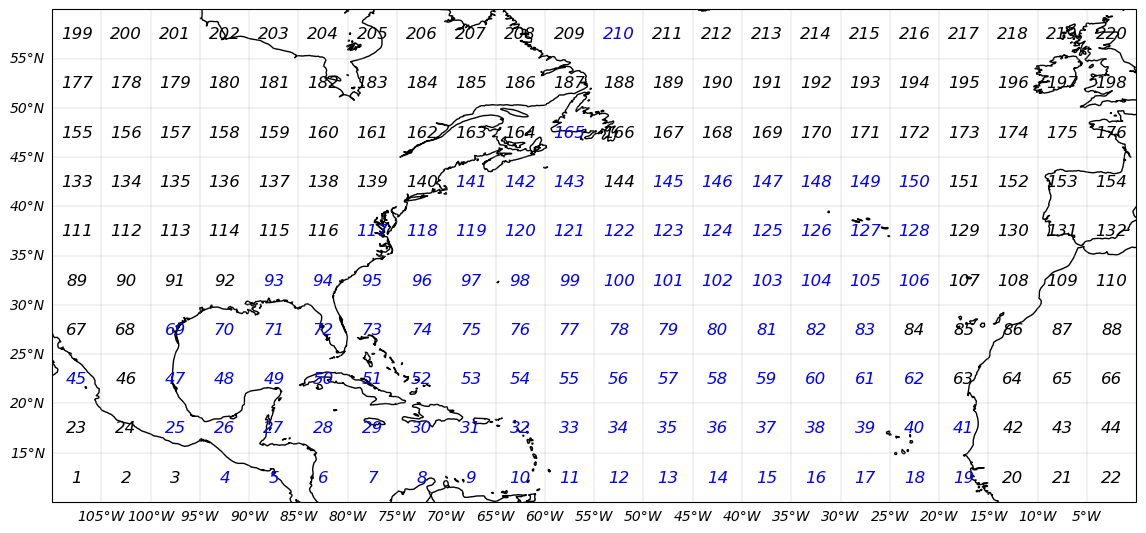

In [11]:
# West plot
print('Plotting West intensities')
# Extracting the values : 
# Successful regressions : 
xWS = success_W_grids['longitude']
yWS = success_W_grids['latitude']
mWS = success_W_grids['grid_ids']

# Failed regressions : 
xWF = failed_W_grids['longitude']
yWF = failed_W_grids['latitude']
mWF = failed_W_grids['grid_ids']

# Plotting :
fig_width = 16
fig_height = (4/10)*fig_width
fig = plt.figure(figsize=(fig_width,fig_height))

ax = plt.axes(projection=ccrs.PlateCarree()) 
ax.set_extent([-max_long, min_long, min_lat, max_lat], crs = ccrs.PlateCarree()) 
gl = ax.gridlines(xlocs = -long_range, ylocs = lat_range, draw_labels=True,linewidth=0.25)

gl.top_labels = False
gl.right_labels = False

for i in range(xWS.shape[0]) : 
    plt.text(-xWS[i],yWS[i],mWS[i],
             horizontalalignment= 'center',
             verticalalignment = 'center',
             weight = 400,                  # Make the text bolder
             fontsize = 12,
             color = 'blue',
            transform=ccrs.PlateCarree())

for i in range(xWF.shape[0]) : 
    plt.text(-xWF[i],yWF[i],mWF[i],
             horizontalalignment= 'center',
             verticalalignment = 'center',
             weight = 400,                  # Make the text bolder
             fontsize = 12,
             color = 'black',
            transform=ccrs.PlateCarree())
    
ax.coastlines()

Plotting East intensities


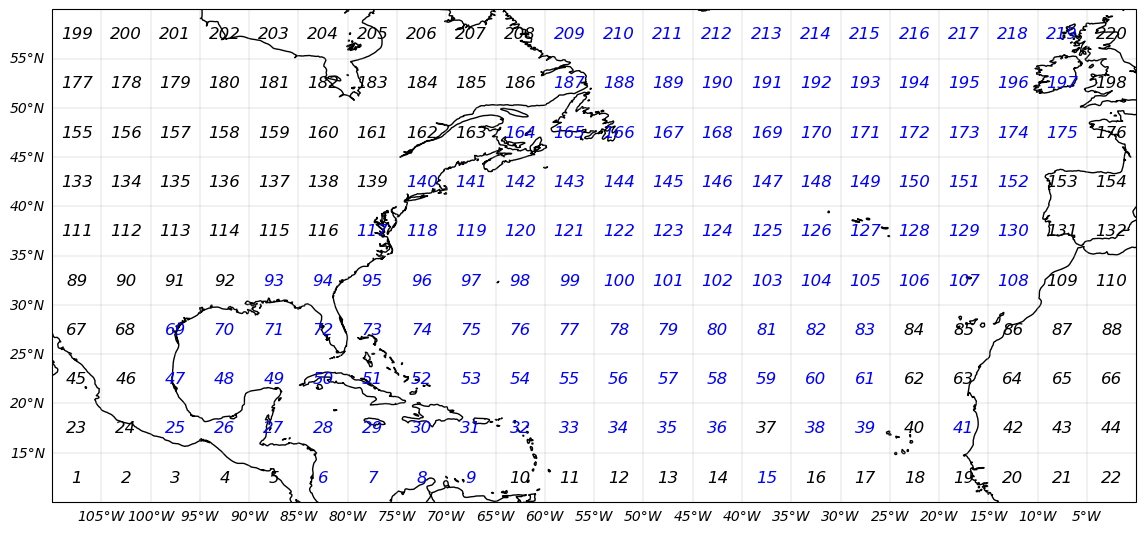

In [12]:
# East plot
print('Plotting East intensities')
# Extracting the values : 
# Successful regressions : 
xES = success_E_grids['longitude']
yES = success_E_grids['latitude']
mES = success_E_grids['grid_ids']

# Failed regressions : 
xEF = failed_E_grids['longitude']
yEF = failed_E_grids['latitude']
mEF = failed_E_grids['grid_ids']

# Plotting :
fig_width = 16
fig_height = (4/10)*fig_width
fig = plt.figure(figsize=(fig_width,fig_height))

ax = plt.axes(projection=ccrs.PlateCarree()) 
ax.set_extent([-max_long, min_long, min_lat, max_lat], crs = ccrs.PlateCarree()) 
gl = ax.gridlines(xlocs = -long_range, ylocs = lat_range, draw_labels=True,linewidth=0.25)

gl.top_labels = False
gl.right_labels = False

for i in range(xES.shape[0]) : 
    plt.text(-xES[i],yES[i],mES[i],
             horizontalalignment= 'center',
             verticalalignment = 'center',
             weight = 400,                  # Make the text bolder
             fontsize = 12,
             color = 'blue',
            transform=ccrs.PlateCarree())

for i in range(xEF.shape[0]) : 
    plt.text(-xEF[i],yEF[i],mEF[i],
             horizontalalignment= 'center',
             verticalalignment = 'center',
             weight = 400,                  # Make the text bolder
             fontsize = 12,
             color = 'black',
            transform=ccrs.PlateCarree())
    
ax.coastlines()

# Assigning coefficients to grids missing regression information

In [13]:
# Define some parameters related to grid geometry : 
first_row_max = nb_width_cell
final_row_min = nb_cells - nb_width_cell+1
row_ends = np.arange(0,nb_cells+1,nb_width_cell)

In [14]:
# Make a dataframe with the coefficients 
df_init = pd.DataFrame(W_df.loc[:,'grid_ids'])
df_init['W_kappa'] = W_df.loc[:,'Coefficients']
df_init['E_kappa'] = E_df.loc[:,'Coefficients']

# Allocate a row id for each grid cell values : 
corr_grid_row = []
for value in df_init['grid_ids'] : 
    corr_grid_row.append(np.digitize(value,row_ends, right = True))
df_init['grid_row_id'] =corr_grid_row
df_init2 = df_init.copy()
display(df_init2)

# Group the dataframe per rows (so that iterations in next cells only span the grid rows): 
df_init = df_init.groupby('grid_row_id')

,grid_ids,W_kappa,E_kappa,grid_row_id
0,1,NaN,NaN,1
1,2,NaN,NaN,1
2,3,NaN,NaN,1
3,4,"[(676.4994673331512, 0.5049011802417638, -0.01...",NaN,1
4,5,"[(-89.29140736813861, 1.1110888982051392, -0.0...",NaN,1
...,...,...,...,...
215,216,NaN,"[(-112.56998106912852, 0.5094055983508028, 0.2...",10
216,217,NaN,"[(-1.539444555949558, 0.9776066601904194, 0.00...",10
217,218,NaN,"[(99.93002697763586, -9.715778673871682, 10.22...",10
218,219,NaN,"[(87.06582989458548, 1.0086319933708943, -0.00...",10


# Eastward grids

In [15]:
#Rounds of modifications require lists to store the values : 
# Eastern intensity coeffs :
final_EI_coeffs = []
final_EI_coeffs2 = []

#-------------------------------------------------------------
#   Special Edits 

# Row id if a visual check is desired : 
control_id = 0  # 0 = no check at all. 

# Row 1 special edits start at : 
row1_grid_start = 9
# Final row special edits start at : 
#row_n_grid_mod = 16 # ORIGINAL VALUE
row_n_grid_mod = 19

#-------------------------------------------------------------
# Start iterating the grid ids : 

# Select the row groups :
for row_id, item in df_init :    
    #------------------------------------------------------------------
    # We'll do minimal modifications to the first row group - it requires special handling :
    if row_id == 1 :       
        # Take the neighboring cells on the right as the fill values :   
        item.loc[0:row1_grid_start,'E_kappa'] = item.loc[0:row1_grid_start,'E_kappa'].fillna(method = 'bfill')
        final_EI_coeffs.extend(item['E_kappa'])   
    #------------------------------------------------------------------
    # Ensure these rows fill up with a their nearest neighboors on left or right
    if 1 < row_id < 6 :       
        # Take the neighboring cells on the right as the fill values :   
        item.loc[0+(row_id-1)*nb_width_cell:row1_grid_start+(row_id-1)*nb_width_cell,'E_kappa'] = item.loc[0+(row_id-1)*nb_width_cell:row1_grid_start+(row_id-1)*nb_width_cell,'E_kappa'].fillna(method = 'bfill')
        item['E_kappa'].fillna(method = 'ffill',inplace = True)  
        final_EI_coeffs.extend(item['E_kappa'])         
    #------------------------------------------------------------------ 
    # Not all cells need to be filled in this row :
    if 7<= row_id <= row_ends.shape[0]-1 :
        item.loc[nb_width_cell*(row_id)-row_n_grid_mod:nb_width_cell*(row_id),'E_kappa'] = item.loc[nb_width_cell*(row_id)-row_n_grid_mod:nb_width_cell*(row_id),'E_kappa'].fillna(method = 'bfill')
        item['E_kappa'].fillna(method = 'ffill',inplace = True)       
        
        nb_width_cell*(row_id-1)-row_n_grid_mod
        
        
        final_EI_coeffs.extend(item['E_kappa'])  
    #------------------------------------------------------------------    
    # Unique strategy : look right, then left! 
    if 6 <= row_id < 7 :
        
        # Screenshot of "before" : 
        if row_id == control_id : 
            display(item)
        
        # Take the neighboring cells on the left as the fill values for the remaining cells : 
        item['E_kappa'].fillna(method = 'ffill',inplace = True)                
        final_EI_coeffs.extend(item['E_kappa'])
        
        # Screenshot of "after" : 
        if row_id == control_id : 
            display(item)

# End of first pass : 
df_init2['E_kappa_ed'] = final_EI_coeffs        
#--------------------------------------------------------------------------------------------
# 2nd pass : this time, we take care of the remaining rows which require specific attention : 
# 2nd pass required because some of the overwritten values of 1st pass are required to perform next modifications : 
df_init3 = df_init2.copy()
df_init3 = df_init3.groupby('grid_row_id')

# Iterate the groups : 
for row_id, item in df_init3 :    
    #------------------------------------------------------------------
    # We'll do the final modifications on row 1 :
    if row_id == 1 :
        # If row_id == 1, we need to go search the row ABOVE for the values, thus : 
        target_item = df_init3.get_group(row_id+1)
        
        # We aim to change :
        item.loc[row1_grid_start:nb_width_cell+1,'E_kappa_ed'] = np.where(
            # With the condition that :
            item.loc[row1_grid_start:nb_width_cell+1,'E_kappa_ed'].isna(),
            # If true :
            target_item.loc[row1_grid_start+nb_width_cell:(nb_width_cell+nb_width_cell),'E_kappa_ed'],
            # If false :
            item.loc[row1_grid_start:nb_width_cell+1,'E_kappa_ed']
        )        
        final_EI_coeffs2.extend(item['E_kappa_ed'])     
    #------------------------------------------------------------------
    else :            
        final_EI_coeffs2.extend(item['E_kappa_ed'])
    
df_init2['E_kappa_ed2'] = final_EI_coeffs2        

# Westward grids

In [16]:
#Rounds of modifications require lists to store the values : 
# Western intensity coeffs :
final_WI_coeffs = []
final_WI_coeffs2 = []

#-------------------------------------------------------------
#   Special Edits 

# Row id if a visual check is desired : 
control_id = 0  # 0 = no check at all. 

# Row 1 special edits start at : 
row1_grid_start = 9

# Final column special edits begin from (starting from the left) : 
#row_n_grid_mod = 16 # ORIGINAL VALUE
row_n_grid_mod = 19

# Final rows special edits : 
final_groups_to_edit = 3 # Number of row groups to avoid iterating with the base strategy.
#-------------------------------------------------------------
# Start iterating the grid ids : 

# Select the row groups :
for row_id, item in df_init : 
    #------------------------------------------------------------------

    # Unique strategy : look right, then left! 
    if row_id < 5 :        
        # Take the neighboring cells on the right as the fill values : 
        item['W_kappa'].fillna(method = 'ffill',inplace = True)
        # Take the neighboring cells on the left as the fill values for the remaining cells : 
        item['W_kappa'].fillna(method = 'bfill',inplace = True)        
        
        final_WI_coeffs.extend(item['W_kappa'])

        
    elif 5 <= row_id <= row_ends.shape[0]-final_groups_to_edit-1 : 
        # Take the neighboring cells on the right as the fill values : 
        item['W_kappa'].fillna(method = 'ffill',inplace = True)         
        
        # Modify some of the coefficients, not all are needed as there are several land masses on the left of the grid.
        item.loc[nb_width_cell*(row_id)-row_n_grid_mod:nb_width_cell*(row_id),'W_kappa'] = item.loc[nb_width_cell*(row_id)-row_n_grid_mod:nb_width_cell*(row_id),'W_kappa'].fillna(method = 'bfill')
       
        final_WI_coeffs.extend(item['W_kappa'])        

    else : 
        final_WI_coeffs.extend(item['W_kappa'])        

df_init2['W_kappa_ed'] = final_WI_coeffs

#--------------------------------------------------------------------------------------------
# 2nd pass : this time, we take care of the remaining rows which require specific attention : 
# 2nd pass required because some of the overwritten values of 1st pass are required to perform next modifications : 
df_init3 = df_init2.copy()
df_init3 = df_init3.groupby('grid_row_id')

# Iterate the groups : 
for row_id, item in df_init3 :
    #------------------------------------------------------------------
    # We'll do the final modifications on the last rows :
    if row_id >= row_ends.shape[0]-final_groups_to_edit :
        # Search the row BELOW for the values, thus : 
        #target_item = df_init3.get_group(row_id-1)
        
        # Dealing with rows which are pure replica of the previous : 
        # Put in a Series format, allowing to cast in a dataframe the tuples of coefficients :
        filler_WI_series = pd.Series(final_WI_coeffs2[-nb_width_cell:])
        filler_WI_df = pd.DataFrame(filler_WI_series)        
        
        
        # We aim to change :
        item.loc[nb_width_cell*(row_id-1):nb_width_cell*row_id+1,'W_kappa_ed'] = np.where(
            # With the condition that :
            item.loc[nb_width_cell*(row_id-1):nb_width_cell*row_id+1,'W_kappa_ed'].isna(),
            # If true :
            filler_WI_df.iloc[0:nb_width_cell,0],
            # If false :
            item.loc[0+nb_width_cell*(row_id-1):nb_width_cell*row_id+1,'W_kappa_ed']
        )        
      
        final_WI_coeffs2.extend(item['W_kappa_ed'])         
    else :
        final_WI_coeffs2.extend(item['W_kappa_ed'])        
df_init2['W_kappa_ed2'] = final_WI_coeffs2 

In [17]:
# Put everything together  : 
grid_data['E_kappa_coeffs_ed'] = df_init2['E_kappa_ed2']
grid_data['W_kappa_coeffs_ed'] = df_init2['W_kappa_ed2']
grid_data.to_excel('grid_data_edited_v3_V_Imin_RH080_allpc.xlsx', index = False)